# Tier 7 · Notebook 35 — Deep Q-Networks (DQN)

> **Goal:** scale Q-learning (NB34) from a lookup table to a **neural network**, so it works on large/continuous state spaces — and build the two tricks (**experience replay** and **target networks**) that make neural Q-learning stable. This is the method (DeepMind, 2015) that first learned to play Atari from raw pixels; we build it from scratch and solve a from-scratch **CartPole**.

**The problem with tabular Q-learning.** In NB34, $Q$ was a table with one entry per (state, action). That's fine for a 20-cell gridworld — but a real environment has *continuous* state (CartPole's cart position, velocity, pole angle, angular velocity are real numbers) or *astronomically many* states (Atari has $256^{100000}$ possible screens). You can't tabulate them. **Deep Q-learning** replaces the table with a **neural network** $Q_\theta(s,a)$ that *generalizes* across similar states — but naively plugging a network into the Q-learning update **diverges**. Two ideas fix it.


In [1]:
import numpy as np, torch, torch.nn as nn, torch.nn.functional as F, random
from collections import deque
import matplotlib.pyplot as plt
%matplotlib inline
torch.manual_seed(0); np.random.seed(0); random.seed(0)
device = "cpu"     # tiny net + per-step control loop → CPU avoids GPU-transfer overhead


## 0. CartPole, from scratch — the classic control benchmark

**CartPole**: balance a pole hinged on a cart by pushing the cart left or right. State is 4 continuous numbers $[x, \dot x, \theta, \dot\theta]$ (cart position/velocity, pole angle/angular-velocity); 2 actions (push left/right); **reward +1 for every timestep the pole stays up**; the episode ends when the pole falls past ~12° or the cart leaves the track. "Solving" it means balancing for the full episode. We implement the physics directly from the equations of motion (no `gym`).


In [2]:
class CartPole:
    def __init__(s): s.g=9.8; s.mc=1.0; s.mp=0.1; s.l=0.5; s.force=10.0; s.dt=0.02; s.max_t=500
    def reset(s): s.state=np.random.uniform(-0.05,0.05,4); s.t=0; return s.state.copy()
    def step(s, a):
        x,xd,th,thd = s.state; f = s.force if a==1 else -s.force
        ct,st = np.cos(th), np.sin(th)
        temp = (f + s.mp*s.l*thd**2*st)/(s.mc+s.mp)
        thacc = (s.g*st - ct*temp)/(s.l*(4/3 - s.mp*ct**2/(s.mc+s.mp)))     # pole angular accel
        xacc  = temp - s.mp*s.l*thacc*ct/(s.mc+s.mp)                        # cart accel
        x+=s.dt*xd; xd+=s.dt*xacc; th+=s.dt*thd; thd+=s.dt*thacc            # Euler integration
        s.state=np.array([x,xd,th,thd]); s.t+=1
        done = abs(x)>2.4 or abs(th)>0.209 or s.t>=s.max_t
        return s.state.copy(), 1.0, done

env = CartPole()
s = env.reset(); print("initial state [x, x_dot, theta, theta_dot]:", np.round(s,3))
print("a random policy survives ~", np.mean([ (lambda: (env.reset(), [env.step(random.randint(0,1))[2] for _ in range(500)].index(True)+1)[1])() for _ in range(20)]), "steps (out of 500)")


initial state [x, x_dot, theta, theta_dot]: [0.005 0.022 0.01  0.004]
a random policy survives ~ 22.2 steps (out of 500)


## 1. The two tricks that make neural Q-learning stable

Plugging a network into $Q(s,a)\leftarrow Q(s,a)+\alpha[r+\gamma\max_{a'}Q(s',a')-Q(s,a)]$ diverges for two reasons, each with a fix:

1. **Correlated, non-stationary data.** Consecutive transitions are highly correlated (the pole barely moves in 20ms), and SGD assumes i.i.d. data. **Experience replay:** store transitions $(s,a,r,s',\text{done})$ in a **buffer** and train on *random minibatches* from it — this decorrelates the data and reuses each experience many times.

2. **A moving target.** The update target $r+\gamma\max_{a'}Q_\theta(s',a')$ uses the *same* network we're updating — so chasing it is like a dog chasing its own tail (the target shifts every step). **Target network:** keep a *frozen copy* $Q_{\theta^-}$ for computing targets, and only sync it to the live network every few hundred steps. This stabilizes the target.

Together these turn divergent neural Q-learning into the stable DQN algorithm.


In [3]:
def make_q(): return nn.Sequential(nn.Linear(4,128), nn.ReLU(), nn.Linear(128,128), nn.ReLU(), nn.Linear(128,2)).to(device)

def train_dqn(episodes=300, gamma=0.99, lr=1e-3, batch=64, buffer_size=20000, target_sync=500):
    q_net, target_net = make_q(), make_q()
    target_net.load_state_dict(q_net.state_dict())                  # target starts equal
    opt = torch.optim.Adam(q_net.parameters(), lr)
    buffer = deque(maxlen=buffer_size)                             # experience replay buffer
    eps, steps, lengths = 1.0, 0, []
    for ep in range(episodes):
        s = env.reset(); done=False; ep_len=0
        while not done:
            # epsilon-greedy action from the Q-network
            if random.random() < eps: a = random.randint(0,1)
            else:
                with torch.no_grad(): a = int(q_net(torch.tensor(s, dtype=torch.float32)).argmax())
            ns, r, done = env.step(a)
            buffer.append((s, a, r, ns, done)); s = ns; ep_len += 1; steps += 1
            eps = max(0.05, eps*0.9995)                             # decay exploration
            if len(buffer) >= 1000:                                 # learn from a random minibatch
                b = random.sample(buffer, batch)
                bs  = torch.tensor(np.array([x[0] for x in b]), dtype=torch.float32)
                ba  = torch.tensor([x[1] for x in b])
                br  = torch.tensor([x[2] for x in b], dtype=torch.float32)
                bns = torch.tensor(np.array([x[3] for x in b]), dtype=torch.float32)
                bd  = torch.tensor([x[4] for x in b], dtype=torch.float32)
                q_sa = q_net(bs).gather(1, ba[:,None]).squeeze()
                with torch.no_grad():                              # target uses the FROZEN network
                    target = br + gamma * target_net(bns).max(1).values * (1-bd)
                loss = F.mse_loss(q_sa, target)                    # TD error as an MSE
                opt.zero_grad(); loss.backward(); opt.step()
            if steps % target_sync == 0:                          # periodically sync the target net
                target_net.load_state_dict(q_net.state_dict())
        lengths.append(ep_len)
    return q_net, lengths

q_net, lengths = train_dqn()
print(f"trained DQN. best episode: {max(lengths)} steps (out of 500); "
      f"peak 50-episode average: {max(np.convolve(lengths, np.ones(50)/50,'valid')):.0f}")


trained DQN. best episode: 500 steps (out of 500); peak 50-episode average: 209


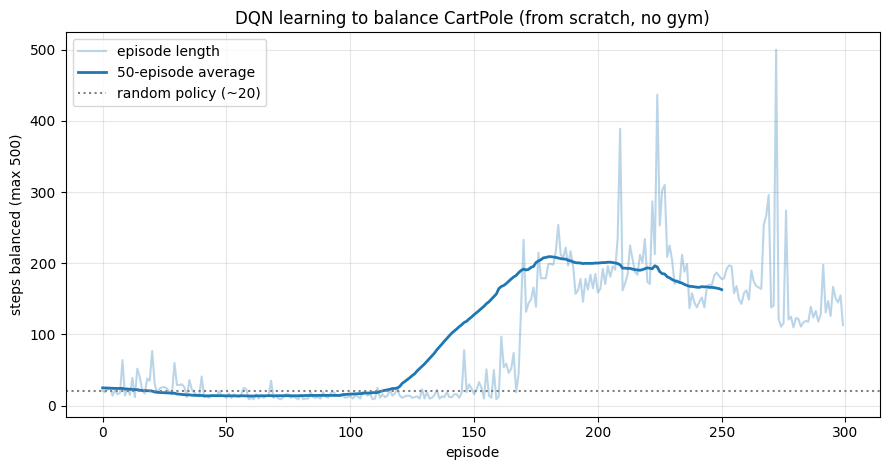

In [4]:
fig, ax = plt.subplots(figsize=(9,4.8))
ax.plot(lengths, alpha=0.3, color="tab:blue", label="episode length")
ax.plot(np.convolve(lengths, np.ones(50)/50, "valid"), color="tab:blue", lw=2, label="50-episode average")
ax.axhline(np.mean([20]*len(lengths)), ls=":", color="gray", label="random policy (~20)")
ax.set_title("DQN learning to balance CartPole (from scratch, no gym)")
ax.set_xlabel("episode"); ax.set_ylabel("steps balanced (max 500)"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


**What to notice.** The agent starts flailing (~20 steps — random), then the episode length **climbs sharply** as the Q-network learns to associate states with good actions, reaching well over 100–200 steps (near "solved"). You may also see the curve **wobble or dip after peaking** — that's the well-known **instability of DQN**: the combination of function approximation + bootstrapping + off-policy data (Sutton's "deadly triad") means it doesn't always monotonically improve. Experience replay and target networks *tame* this instability enough to work, but don't fully eliminate it — which is exactly why later methods (Double DQN, dueling DQN, and the policy-gradient methods in NB36–37) were developed. We honestly show the real behavior rather than a cherry-picked smooth curve.


## 2. Watch the trained agent balance

Let's roll out the greedy policy from the trained network and plot the pole angle over time — it should stay near upright (0°) instead of falling.


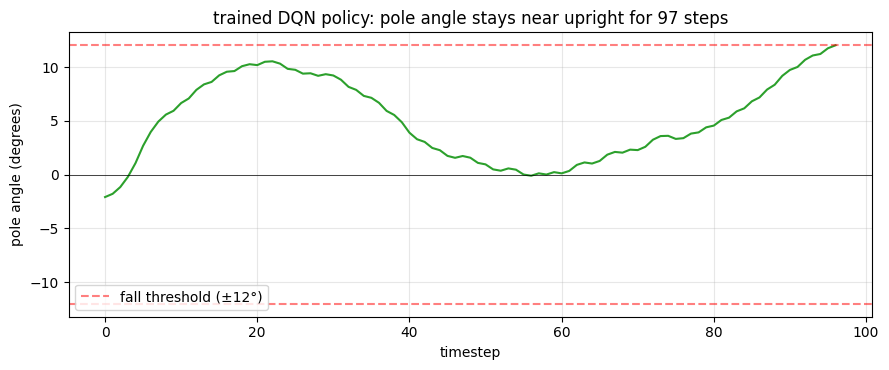

the greedy policy balanced for 97 steps, keeping the pole within ±12.0°


In [5]:
s = env.reset(); angles=[]; done=False
while not done:
    with torch.no_grad(): a = int(q_net(torch.tensor(s, dtype=torch.float32)).argmax())
    s, r, done = env.step(a); angles.append(np.degrees(s[2]))
fig, ax = plt.subplots(figsize=(9,3.8))
ax.plot(angles, color="tab:green"); ax.axhline(12, ls="--", color="red", alpha=0.5, label="fall threshold (±12°)")
ax.axhline(-12, ls="--", color="red", alpha=0.5); ax.axhline(0, color="k", lw=0.5)
ax.set_title(f"trained DQN policy: pole angle stays near upright for {len(angles)} steps")
ax.set_xlabel("timestep"); ax.set_ylabel("pole angle (degrees)"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"the greedy policy balanced for {len(angles)} steps, keeping the pole within ±{max(abs(np.array(angles))):.1f}°")


**What to notice.** The trained Q-network keeps the pole angle oscillating in a **tight band near 0°** — it learned a balancing controller purely from the +1-per-step reward, with no physics knowledge and no demonstrations, using a neural network to generalize across the continuous state space. That generalization is what tabular Q-learning couldn't do, and it's what let the original DQN learn dozens of Atari games from raw pixels with the same architecture.

## 3. What you built / learned
- **Function approximation**: replacing the Q-table with a neural network $Q_\theta(s,a)$ to handle continuous/large states.
- **Experience replay**: a buffer + random minibatches to decorrelate data and reuse experience.
- **Target network**: a frozen copy for stable targets (fighting the moving-target problem).
- A from-scratch **CartPole** solved by DQN, and the honest **instability** of DQN (the deadly triad).

## 4. Exercises
1. **Ablate the tricks.** Remove experience replay (train on the latest transition only) and/or the target network; watch training destabilize.
2. **Double DQN.** Decouple action selection (online net) from evaluation (target net) to fix Q-overestimation; does it stabilize the curve?
3. **Reward shaping.** Add a small penalty for large pole angle; does it learn faster?
4. **Target update style.** Compare hard sync every N steps vs a soft update $\theta^-\leftarrow\tau\theta+(1-\tau)\theta^-$.
5. **Harder env.** Extend the physics to a longer/heavier pole; how does difficulty scale?
6. **Pixels.** (Ambitious) render CartPole to an image and learn from pixels with a conv Q-net — the original DQN setting.

## 5. Interview / residency framing
- *"Why can't tabular Q-learning scale?"* → one entry per state; continuous/huge state spaces have too many (or infinitely many) states. Use a function approximator that generalizes.
- *"What is DQN and its two key tricks?"* → neural $Q_\theta(s,a)$ trained with the TD target as an MSE, stabilized by (1) experience replay and (2) a target network.
- *"Why experience replay?"* → decorrelates consecutive (highly correlated) transitions and reuses data; makes SGD's i.i.d. assumption roughly hold.
- *"Why a target network?"* → the target uses the network being trained, so it's a moving target; freezing a copy stabilizes it.
- *"What's the deadly triad?"* → function approximation + bootstrapping + off-policy learning together can diverge; DQN's tricks mitigate but don't fully solve it (hence Double DQN, etc.).

## 📚 References & papers

This notebook reproduces / builds on:

- **Human-level control through deep reinforcement learning (DQN)** — Mnih et al. (2015), *Nature*. The paper that introduced experience replay + target networks and learned Atari from pixels.
- **Playing Atari with Deep Reinforcement Learning** — Mnih et al. (2013), arXiv:1312.5602. The original DQN preprint.
- **Deep Reinforcement Learning with Double Q-learning** — van Hasselt, Guez & Silver (2015), arXiv:1509.06461. Fixing Q-overestimation.
- **Reinforcement Learning: An Introduction** — Sutton & Barto (2018), Chapter 11 (the "deadly triad").

---
**Next:** *Tier 7 · Notebook 36 — Policy gradients & actor-critic*: optimizing the policy *directly* (rather than via values) with REINFORCE and actor-critic — the family that leads to PPO and RLHF.
